In [1]:
import os
import numpy as np
import d3rlpy
import csv
import matplotlib.pyplot as plt
import pandas as pd
import re

def read_Episodes(baseFolder):
    """Liest alle Episoden aus einem Ordner und gibt sie als Array zurück.
    Stoppt bei terminal == 1 (inklusive der ersten terminal=1 Zeile).
    """
    episodes = []
    headers = None
    filenames = []
    
    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []
        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            file_headers = next(reader)  # Read header row
            
            # Store headers from first file
            if headers is None:
                headers = file_headers
            
            for row in reader:
                observation = [float(value) for value in row]
                episode.append(observation)
                    
            episodes.append(episode)
            filenames.append(filename)
    
    return episodes, headers, filenames

def load_models_from_training(training_dir):
    models = []
    model_files = [f for f in os.listdir(training_dir) if f.endswith('.d3')]
    
    # Funktion zum Extrahieren der größten Nummer aus dem Dateinamen
    def extract_number(filename):
        numbers = re.findall(r'\d+', filename)
        # Nimm die größte gefundene Zahl (nicht die letzte)
        return max([int(n) for n in numbers]) if numbers else 0
        
    # Nach der größten Nummer im Dateinamen sortieren und das letzte nehmen
    if model_files:
        model_files_sorted = sorted(model_files, key=extract_number)
        model_file = model_files_sorted[-1]
        model_path = os.path.join(training_dir, model_file)
        model_file = os.path.split(training_dir)[1]+"/"+model_file
        try:
            model = d3rlpy.load_learnable(model_path)
            models.append((model_file, model))
            print(f"  -> Selected: {model_file}")
        except Exception as e:
            print(f"Error loading {model_file}: {e}")
    return models

# ==== Hauptfunktion ====
base_dir = "logs/8 single epi simulated_top3_algos_final/d3rlpy_logs_500k"  # Passe ggf. an

# Zwei Datensätze: Simuliert und Gemessen
testEpisode_simulated = "../data/episFormula/testSingleEpi simulated"
testEpisode_measured = "../data/episFormula/8 single epi measured"

# Episoden laden (simuliert)
episodes_sim, headers, episode_filenames_sim = read_Episodes(testEpisode_simulated)

# Episoden laden (gemessen)
episodes_meas, headers_meas, episode_filenames_meas = read_Episodes(testEpisode_measured)

# Spalten-Definitionen (wie in trainSingleEpisode)
obs_columns = ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain']
action_column = 'timeToIrri'
reward_column = 'reward'
terminal_column = 'terminal'
ideal_irri_column = 'idealIrri'

# Index-Mappings aus Headers
obs_indices = [headers.index(col) for col in obs_columns]
action_index = headers.index(action_column)
reward_index = headers.index(reward_column)
terminal_index = headers.index(terminal_column)
ideal_irri_index = headers.index(ideal_irri_column)

print(f"Headers: {headers}")
print(f"Observation columns: {obs_columns} -> indices: {obs_indices}")
print(f"Action column: {action_column} -> index: {action_index}")
print(f"IdealIrri column: {ideal_irri_column} -> index: {ideal_irri_index}")
print(f"Anzahl Episoden (simuliert): {len(episodes_sim)}")
print(f"Anzahl Episoden (gemessen): {len(episodes_meas)}")

def evaluate_model_on_episodes(model, episodes, episode_filenames, obs_indices, terminal_index):
    """Evaluiert ein Modell auf einem Episodendatensatz und gibt Metriken zurück."""
    soll_ist_diff = []
    episode_deviations = []
    totalError = 0
    wrongEpisode = 0
    
    for epi_idx, epi in enumerate(episodes):
        prediction = []
        for sample in epi:
            obs = np.array([[sample[idx] for idx in obs_indices]])
            try:
                pred = model.predict(obs)[0]
            except Exception as e:
                pred = 0
            prediction.append(pred)
        
        soll_idx = next((i for i, v in enumerate([sample[terminal_index] for sample in epi]) if v > 0), None)
        ist_idx = next((i for i, v in enumerate(prediction) if v <= 10), None)
        
        if ist_idx is None:
            totalError += 1
            episode_deviations.append((epi_idx, episode_filenames[epi_idx], None, "Kein Trigger"))
        elif soll_idx is None:
            wrongEpisode += 1
            episode_deviations.append((epi_idx, episode_filenames[epi_idx], None, "Kein Soll"))
        else:
            abweichung = ist_idx + 1 - soll_idx
            abweichung_min = abweichung * 10
            # Prüfe ob Abweichung größer als ±90 Minuten
            if abweichung_min > 90 or abweichung_min < -90:
                totalError += 1
                episode_deviations.append((epi_idx, episode_filenames[epi_idx], abweichung_min, "Error (>±90min)"))
            else:
                soll_ist_diff.append(abweichung_min)
                episode_deviations.append((epi_idx, episode_filenames[epi_idx], abweichung_min, "OK" if -10 <= abweichung_min <= 10 else "Außerhalb"))
    
    n_valid = len(episodes) - wrongEpisode
    return soll_ist_diff, episode_deviations, totalError, wrongEpisode, n_valid

# Globale Sammlung für die Vergleichstabelle - Simuliert
results_sim = {"algo_names": [], "model_names": [], "error_rates": [], "median_offset": [], 
               "mean_offset": [], "std_offset": [], "within_10min": [], "within_20min": [], 
               "within_30min": [], "soll_ist_diffs": [], "episode_deviations": []}

# Globale Sammlung für die Vergleichstabelle - Gemessen
results_meas = {"algo_names": [], "model_names": [], "error_rates": [], "median_offset": [], 
                "mean_offset": [], "std_offset": [], "within_10min": [], "within_20min": [], 
                "within_30min": [], "soll_ist_diffs": [], "episode_deviations": []}

if os.path.exists(base_dir):
    algorithm_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    for algorithm_name in algorithm_dirs:
        algorithm_path = os.path.join(base_dir, algorithm_name)
        print(f"\nProcessing algorithm: {algorithm_name}")
        models = load_models_from_training(algorithm_path)
        if not models:
            print(f"No models found in {algorithm_path}")
            continue
        
        for i, (model_name, model) in enumerate(models):
            # === Evaluierung auf SIMULIERTEN Daten ===
            soll_ist_diff_sim, episode_dev_sim, totalError_sim, wrongEpisode_sim, n_valid_sim = \
                evaluate_model_on_episodes(model, episodes_sim, episode_filenames_sim, obs_indices, terminal_index)
            
            if len(soll_ist_diff_sim) > 0 and n_valid_sim > 0:
                error_percent = (totalError_sim / n_valid_sim) * 100
                within_10 = sum(1 for x in soll_ist_diff_sim if -10 <= x <= 10) / n_valid_sim * 100
                within_20 = sum(1 for x in soll_ist_diff_sim if -20 <= x <= 20) / n_valid_sim * 100
                within_30 = sum(1 for x in soll_ist_diff_sim if -30 <= x <= 30) / n_valid_sim * 100
                
                results_sim["algo_names"].append(algorithm_name)
                results_sim["model_names"].append(model_name)
                results_sim["error_rates"].append(round(error_percent, 2))
                results_sim["median_offset"].append(round(np.median(soll_ist_diff_sim), 2))
                results_sim["mean_offset"].append(round(np.mean(soll_ist_diff_sim), 2))
                results_sim["std_offset"].append(round(np.std(soll_ist_diff_sim), 2))
                results_sim["within_10min"].append(round(within_10, 2))
                results_sim["within_20min"].append(round(within_20, 2))
                results_sim["within_30min"].append(round(within_30, 2))
                results_sim["soll_ist_diffs"].append(soll_ist_diff_sim)
                results_sim["episode_deviations"].append(episode_dev_sim)
            
            # === Evaluierung auf GEMESSENEN Daten ===
            soll_ist_diff_meas, episode_dev_meas, totalError_meas, wrongEpisode_meas, n_valid_meas = \
                evaluate_model_on_episodes(model, episodes_meas, episode_filenames_meas, obs_indices, terminal_index)
            
            if len(soll_ist_diff_meas) > 0 and n_valid_meas > 0:
                error_percent = (totalError_meas / n_valid_meas) * 100
                within_10 = sum(1 for x in soll_ist_diff_meas if -10 <= x <= 10) / n_valid_meas * 100
                within_20 = sum(1 for x in soll_ist_diff_meas if -20 <= x <= 20) / n_valid_meas * 100
                within_30 = sum(1 for x in soll_ist_diff_meas if -30 <= x <= 30) / n_valid_meas * 100
                
                results_meas["algo_names"].append(algorithm_name)
                results_meas["model_names"].append(model_name)
                results_meas["error_rates"].append(round(error_percent, 2))
                results_meas["median_offset"].append(round(np.median(soll_ist_diff_meas), 2))
                results_meas["mean_offset"].append(round(np.mean(soll_ist_diff_meas), 2))
                results_meas["std_offset"].append(round(np.std(soll_ist_diff_meas), 2))
                results_meas["within_10min"].append(round(within_10, 2))
                results_meas["within_20min"].append(round(within_20, 2))
                results_meas["within_30min"].append(round(within_30, 2))
                results_meas["soll_ist_diffs"].append(soll_ist_diff_meas)
                results_meas["episode_deviations"].append(episode_dev_meas)
else:
    print(f"Directory {base_dir} not found!")

print(f"\nDatenverarbeitung abgeschlossen.")
print(f"  Simuliert: {len(results_sim['algo_names'])} Modelle verarbeitet.")
print(f"  Gemessen: {len(results_meas['algo_names'])} Modelle verarbeitet.")#

#TODO errro thgreshold auf 1,5h alles drüber gibt einen Error

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Headers: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain', 'timeToIrri', 'reward', 'terminal', 'idealIrri', 'evoCumsum']
Observation columns: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain'] -> indices: [0, 1, 2, 3, 4, 5, 6]
Action column: timeToIrri -> index: 7
IdealIrri column: idealIrri -> index: 10
Anzahl Episoden (simuliert): 3579
Anzahl Episoden (gemessen): 440

Processing algorithm: BCQ_20260213030307


c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\d3rlpy\torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_locatio

  -> Selected: BCQ_20260213030307/model_500000.d3

Processing algorithm: IQL_20260213001109
  -> Selected: IQL_20260213001109/model_500000.d3

Processing algorithm: PLAS_20260212223013
  -> Selected: PLAS_20260212223013/model_497500.d3

Datenverarbeitung abgeschlossen.
  Simuliert: 3 Modelle verarbeitet.
  Gemessen: 3 Modelle verarbeitet.


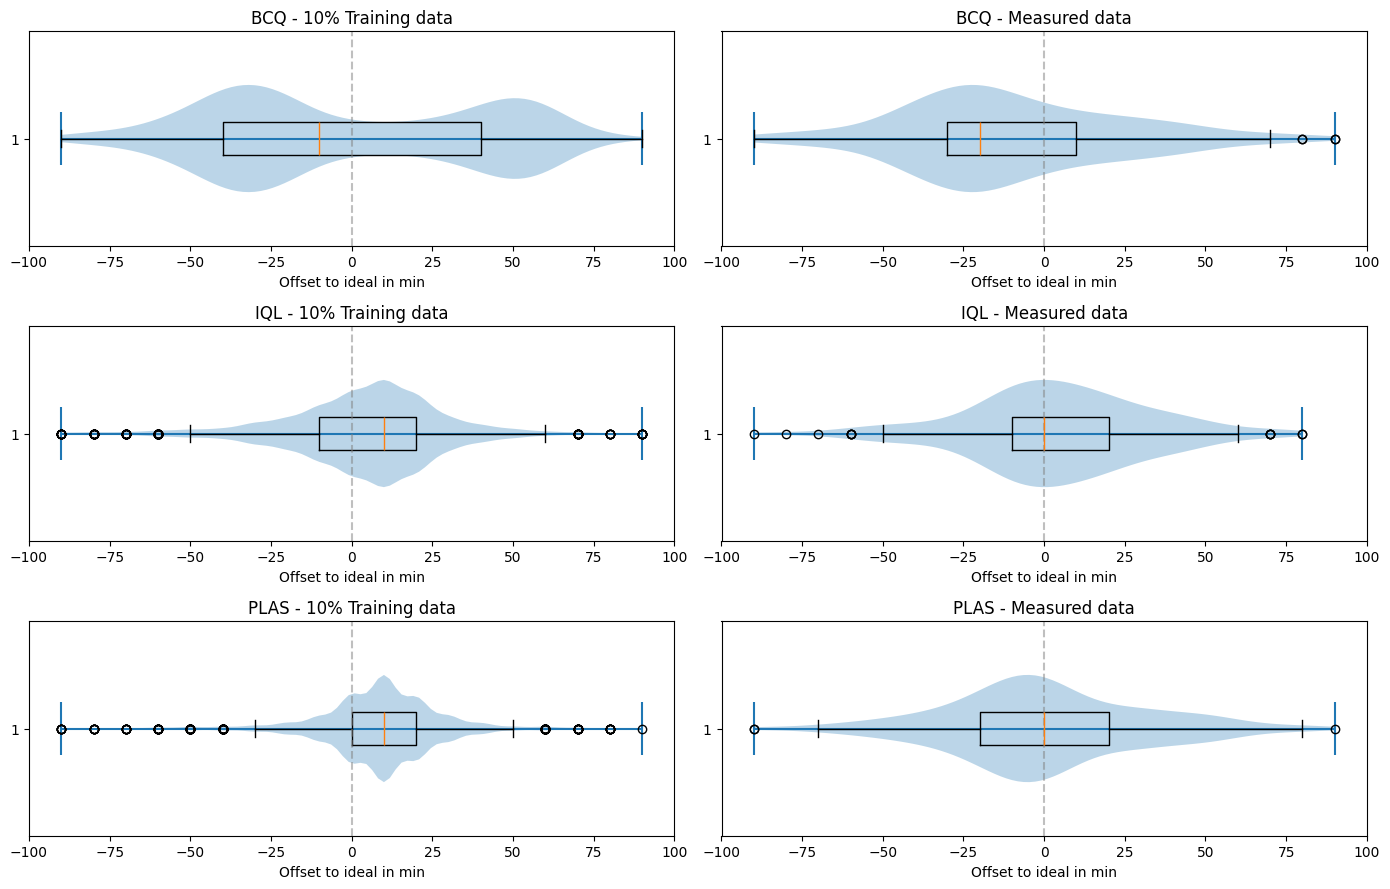

In [2]:
# === Kombinierter Plot: 3 Reihen × 2 Spalten (Simuliert | Gemessen) ===
n_algos = len(results_sim["algo_names"])
fig, axes = plt.subplots(n_algos, 2, figsize=(14, 3*n_algos), squeeze=False)

# Gemeinsamer X-Achsen-Bereich für bessere Vergleichbarkeit
all_diffs = results_sim["soll_ist_diffs"] + results_meas["soll_ist_diffs"]
if all_diffs:
    x_min = min(min(d) for d in all_diffs if d) - 10
    x_max = max(max(d) for d in all_diffs if d) + 10
else:
    x_min, x_max = -100, 100

# Linke Spalte: Simulierte Daten
for i, (algo_name, soll_ist_diff) in enumerate(zip(results_sim["algo_names"], results_sim["soll_ist_diffs"])):
    ax = axes[i, 0]
    ax.violinplot(soll_ist_diff, vert=False)
    ax.boxplot(soll_ist_diff, vert=False)
    ax.set_title(f"{algo_name.split('_')[0]} - 10% Training data")
    ax.set_xlabel("Offset to ideal in min")
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(x_min, x_max)

# Rechte Spalte: Gemessene Daten
for i, (algo_name, soll_ist_diff) in enumerate(zip(results_meas["algo_names"], results_meas["soll_ist_diffs"])):
    ax = axes[i, 1]
    ax.violinplot(soll_ist_diff, vert=False)
    ax.boxplot(soll_ist_diff, vert=False)
    ax.set_title(f"{algo_name.split('_')[0]} - Measured data")
    ax.set_xlabel("Offset to ideal in min")
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

In [3]:
# === Tabellen generieren ===

# Vergleichstabelle: Simulierte Daten
summary_df_sim = pd.DataFrame({
    "Algorithmus": results_sim["algo_names"],
    "Modell": results_sim["model_names"],
    "Error %": results_sim["error_rates"],
    "Within ±10min %": results_sim["within_10min"],
    "Within ±20min %": results_sim["within_20min"],
    "Within ±30min %": results_sim["within_30min"],
    "Median Offset (min)": results_sim["median_offset"],
    "Mean Offset (min)": results_sim["mean_offset"],
    "Std Offset (min)": results_sim["std_offset"],
})
summary_df_sim = summary_df_sim.sort_values("Error %").reset_index(drop=True)
print("===== Vergleichstabelle: SIMULIERT =====")
display(summary_df_sim)

# Vergleichstabelle: Gemessene Daten
summary_df_meas = pd.DataFrame({
    "Algorithmus": results_meas["algo_names"],
    "Modell": results_meas["model_names"],
    "Error %": results_meas["error_rates"],
    "Within ±10min %": results_meas["within_10min"],
    "Within ±20min %": results_meas["within_20min"],
    "Within ±30min %": results_meas["within_30min"],
    "Median Offset (min)": results_meas["median_offset"],
    "Mean Offset (min)": results_meas["mean_offset"],
    "Std Offset (min)": results_meas["std_offset"],
})
summary_df_meas = summary_df_meas.sort_values("Error %").reset_index(drop=True)
print("\n===== Vergleichstabelle: GEMESSEN =====")
display(summary_df_meas)

===== Vergleichstabelle: SIMULIERT =====


,Algorithmus,Modell,Error %,Within ±10min %,Within ±20min %,Within ±30min %,Median Offset (min),Mean Offset (min),Std Offset (min)
0,PLAS_20260212223013,PLAS_20260212223013/model_497500.d3,1.17,58.59,80.30,89.61,10.0,8.58,19.85
1,IQL_20260213001109,IQL_20260213001109/model_500000.d3,1.70,51.24,73.88,84.91,10.0,3.93,24.73
2,BCQ_20260213030307,BCQ_20260213030307/model_500000.d3,6.06,11.29,24.31,40.91,-10.0,-1.68,43.07



===== Vergleichstabelle: GEMESSEN =====


,Algorithmus,Modell,Error %,Within ±10min %,Within ±20min %,Within ±30min %,Median Offset (min),Mean Offset (min),Std Offset (min)
0,BCQ_20260213030307,BCQ_20260213030307/model_500000.d3,37.27,15.45,30.68,41.59,-20.0,-9.96,34.70
1,IQL_20260213001109,IQL_20260213001109/model_500000.d3,44.55,26.36,37.27,42.95,0.0,4.22,28.53
2,PLAS_20260212223013,PLAS_20260212223013/model_497500.d3,46.14,25.00,33.18,40.68,0.0,0.17,31.11


  -> Selected: BCQ_20260214005207/model_1000000.d3
  -> Selected: IQL_20260213191915/model_1000000.d3
  -> Selected: PLAS_20260213151224/model_1000000.d3

Geladene Modelle: ['BCQ', 'IQL', 'PLAS']
Ausgewählte Episode (simuliert): 232 (Länge: 66 Schritte)


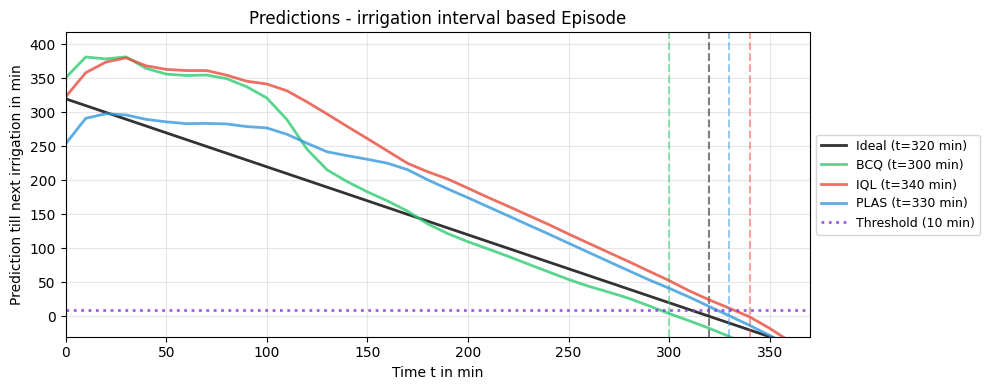


=== Zusammenfassung: Episode 232 (simuliert) ===
Episode-Länge: 66 Schritte
Idealer Bewässerungszeitpunkt: Schritt 32
  BCQ: Trigger bei Schritt 30 (Offset: -2 Schritte = -20 min)
  IQL: Trigger bei Schritt 34 (Offset: +2 Schritte = +20 min)
  PLAS: Trigger bei Schritt 33 (Offset: +1 Schritte = +10 min)


In [ ]:
def plot_episode_with_models(episode, models_dict, obs_indices, ideal_irri_index, episode_name="Episode"):
    """
    Spielt eine einzelne Episode mit verschiedenen Modellen durch und plottet den zeitlichen Verlauf.
    
    Args:
        episode: Liste von Samples (eine Episode)
        models_dict: Dictionary {model_name: model} der zu vergleichenden Modelle
        obs_indices: Liste der Indices für die Observations
        ideal_irri_index: Index für idealIrri im Sample
        episode_name: Name der Episode für den Plot-Titel
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
    
    # Zeitschritte (x-Achse) in Minuten
    time_steps = [i * 10 for i in range(len(episode))]
    
    # Farben für verschiedene Modelle
    colors = {'BCQ': '#2ecc71', 'PLAS': '#3498db', 'IQL': '#e74c3c'}
    
    # timeToIrri (Ground Truth) aus der Episode extrahieren
    time_to_irri = [sample[action_index] for sample in episode]
    
    # Finde den Zeitpunkt wo idealIrri > 0 (optimaler Bewässerungszeitpunkt)
    ideal_idx = next((i for i, v in enumerate(time_to_irri) if v <= 0), None)
    
    # Plot: timeToIrri (Ground Truth) zuerst
    ax1.axvline(x=ideal_idx * 10, color='black', linestyle='--', alpha=0.5)  
    ax1.plot(time_steps, time_to_irri, label=f'Ideal (t={ideal_idx * 10} min)', color='black', linewidth=2, alpha=0.8, linestyle='-')
    
    # Plot: Predictions über Zeit
    for (model_name, model) in models_dict.items():
        color = colors.get(model_name, '#999999')
        predictions = []
        for sample in episode:
            obs = np.array([[sample[idx] for idx in obs_indices]])
            try:
                pred = model.predict(obs)[0]
            except Exception as e:
                pred = np.nan
            predictions.append(pred)

        # Markiere den Zeitpunkt wo Prediction <= 10 (Trigger)
        trigger_idx = next((i for i, v in enumerate(predictions) if v <= 10), None)
        if trigger_idx is not None:
            ax1.axvline(x=trigger_idx * 10, color=color, linestyle='--', alpha=0.5)
        ax1.plot(time_steps, predictions, label=model_name+f' (t={trigger_idx*10} min)', color=color, linewidth=2, alpha=0.8)
                  
    
    # Horizontale Linie bei y=10 (Schwellwert)
    ax1.axhline(y=10, color="#8a34db", linestyle=':', alpha=0.8, linewidth=2, label='Threshold (10 min)')
        
    ax1.set_xlabel('Time t in min')
    ax1.set_ylabel('Prediction till next irrigation in min')
    ax1.set_title('Predictions - irrigation interval based Episode')
    ax1.legend(fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5))
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=-30)
    ax1.set_xlim(right=episode[0][7] + 50, left=0)
    
    plt.tight_layout()
    plt.show()
    
    # Zusammenfassung ausgeben
    print(f"\n=== Zusammenfassung: {episode_name} ===")
    print(f"Episode-Länge: {len(episode)} Schritte")
    if ideal_idx is not None:
        print(f"Idealer Bewässerungszeitpunkt: Schritt {ideal_idx}")
    else:
        print("Kein idealer Bewässerungszeitpunkt gefunden!")
    
    for model_name, model in models_dict.items():
        predictions = []
        for sample in episode:
            obs = np.array([[sample[idx] for idx in obs_indices]])
            try:
                pred = model.predict(obs)[0]
            except:
                pred = np.nan
            predictions.append(pred)
        
        trigger_idx = next((i for i, v in enumerate(predictions) if v <= 10), None)
        if trigger_idx is not None and ideal_idx is not None:
            offset = trigger_idx - ideal_idx
            print(f"  {model_name}: Trigger bei Schritt {trigger_idx} (Offset: {offset:+d} Schritte = {offset*10:+d} min)")
        elif trigger_idx is not None:
            print(f"  {model_name}: Trigger bei Schritt {trigger_idx}")
        else:
            print(f"  {model_name}: Kein Trigger (nie unter Schwellwert 10)")


# === Beispiel-Verwendung ===
# Lade alle Modelle aus dem base_dir
all_models = {}
if os.path.exists(base_dir):
    algorithm_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    for algorithm_name in algorithm_dirs:
        algorithm_path = os.path.join(base_dir, algorithm_name)
        models = load_models_from_training(algorithm_path)
        for model_name, model in models:
            # Verwende Algorithmus-Name als Key
            all_models[algorithm_name.split('_')[0]] = model

print(f"\nGeladene Modelle: {list(all_models.keys())}")

# Wähle eine zufällige Episode aus (simuliert)
import random
#random.seed(42)
episode_idx = random.randint(0, len(episodes_sim)-1)
selected_episode = episodes_sim[914]

print(f"Ausgewählte Episode (simuliert): {episode_idx} (Länge: {len(selected_episode)} Schritte)")

# Plotte die Episode mit allen Modellen
plot_episode_with_models(selected_episode, all_models, obs_indices, ideal_irri_index, f"Episode {episode_idx} (simuliert)")

Plotte 10 zufällige SIMULIERTE Episoden aus 3579 verfügbaren
Ausgewählte Indizes: [177, 396, 1083, 1408, 1470, 1881, 2472, 2988, 3305, 3471]



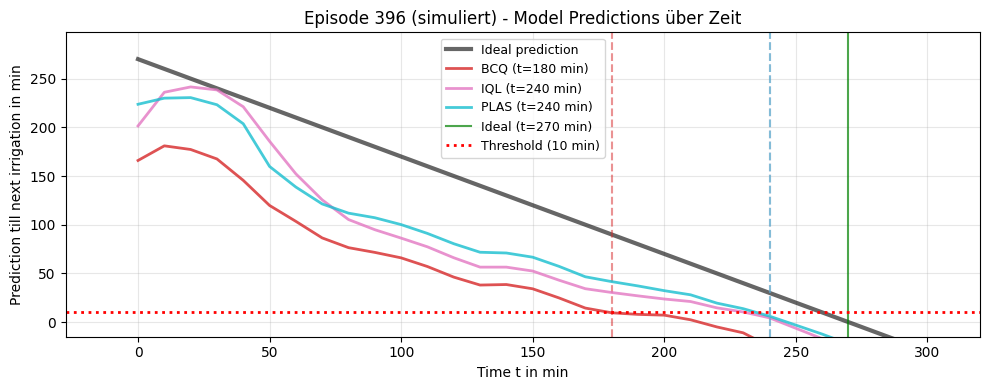


=== Zusammenfassung: Episode 396 (simuliert) ===
Episode-Länge: 56 Schritte
Idealer Bewässerungszeitpunkt: Schritt 27
  BCQ: Trigger bei Schritt 18 (Offset: -9 Schritte = -90 min)
  IQL: Trigger bei Schritt 24 (Offset: -3 Schritte = -30 min)
  PLAS: Trigger bei Schritt 24 (Offset: -3 Schritte = -30 min)
--------------------------------------------------------------------------------


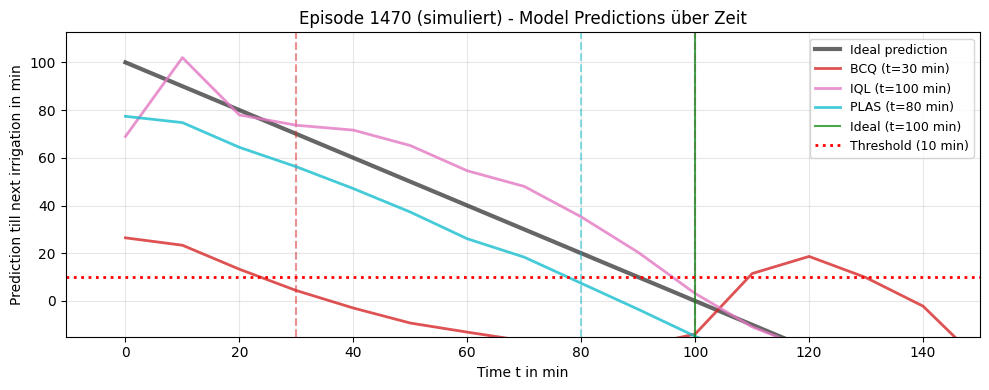


=== Zusammenfassung: Episode 1470 (simuliert) ===
Episode-Länge: 22 Schritte
Idealer Bewässerungszeitpunkt: Schritt 10
  BCQ: Trigger bei Schritt 3 (Offset: -7 Schritte = -70 min)
  IQL: Trigger bei Schritt 10 (Offset: +0 Schritte = +0 min)
  PLAS: Trigger bei Schritt 8 (Offset: -2 Schritte = -20 min)
--------------------------------------------------------------------------------


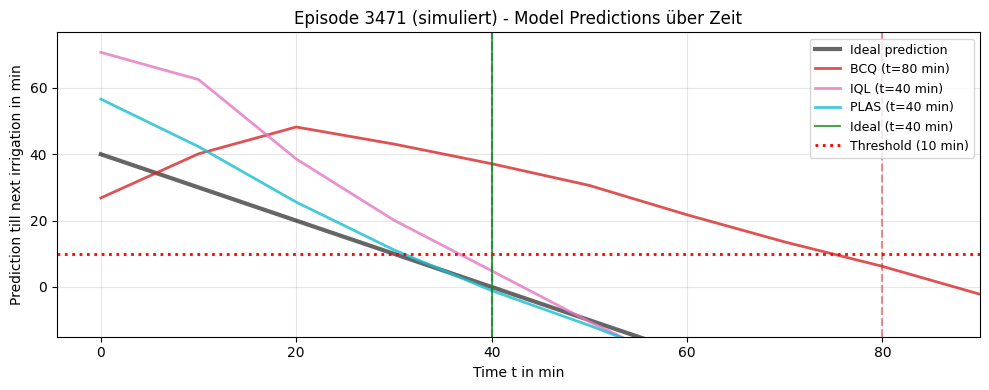


=== Zusammenfassung: Episode 3471 (simuliert) ===
Episode-Länge: 10 Schritte
Idealer Bewässerungszeitpunkt: Schritt 4
  BCQ: Trigger bei Schritt 8 (Offset: +4 Schritte = +40 min)
  IQL: Trigger bei Schritt 4 (Offset: +0 Schritte = +0 min)
  PLAS: Trigger bei Schritt 4 (Offset: +0 Schritte = +0 min)
--------------------------------------------------------------------------------


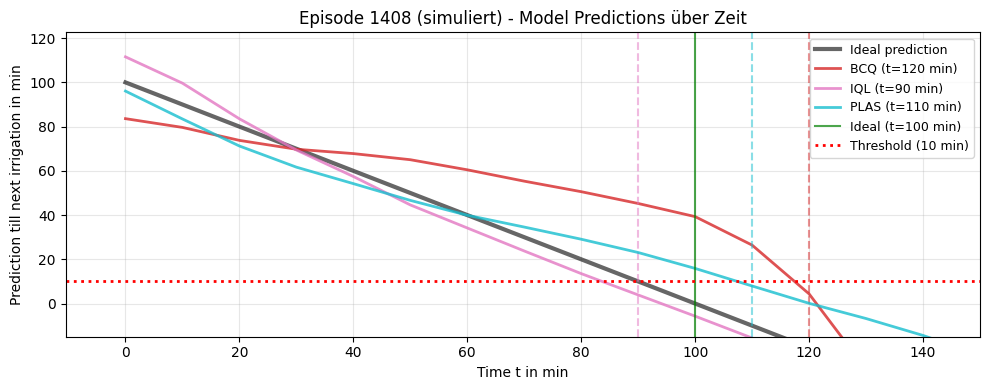


=== Zusammenfassung: Episode 1408 (simuliert) ===
Episode-Länge: 22 Schritte
Idealer Bewässerungszeitpunkt: Schritt 10
  BCQ: Trigger bei Schritt 12 (Offset: +2 Schritte = +20 min)
  IQL: Trigger bei Schritt 9 (Offset: -1 Schritte = -10 min)
  PLAS: Trigger bei Schritt 11 (Offset: +1 Schritte = +10 min)
--------------------------------------------------------------------------------


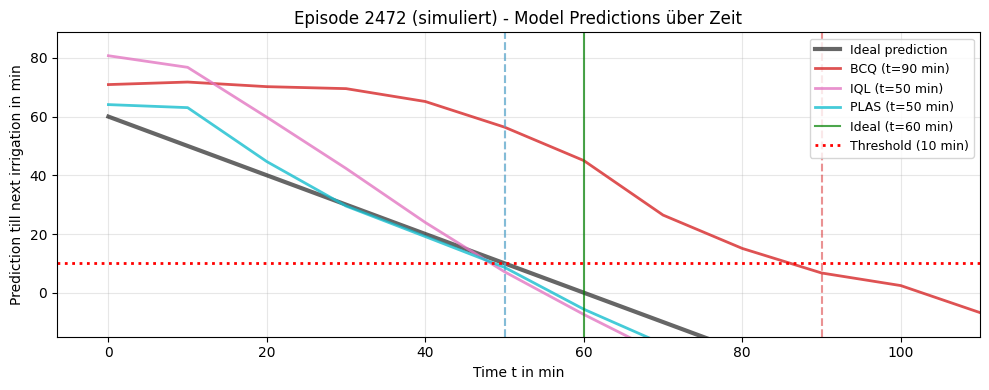


=== Zusammenfassung: Episode 2472 (simuliert) ===
Episode-Länge: 14 Schritte
Idealer Bewässerungszeitpunkt: Schritt 6
  BCQ: Trigger bei Schritt 9 (Offset: +3 Schritte = +30 min)
  IQL: Trigger bei Schritt 5 (Offset: -1 Schritte = -10 min)
  PLAS: Trigger bei Schritt 5 (Offset: -1 Schritte = -10 min)
--------------------------------------------------------------------------------


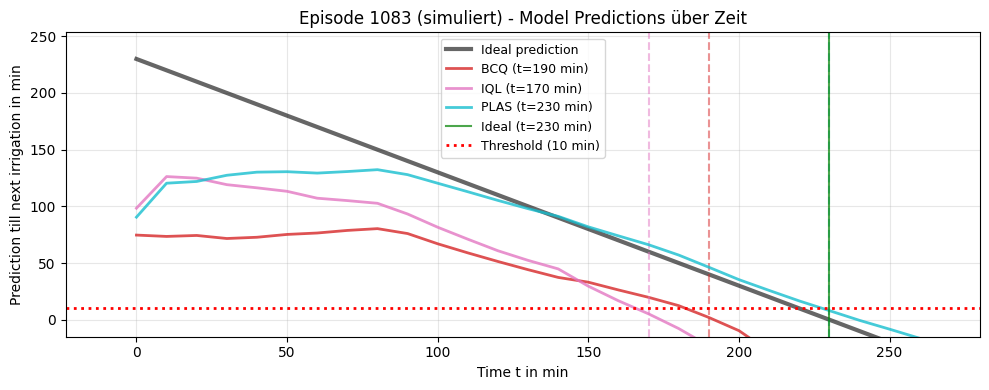


=== Zusammenfassung: Episode 1083 (simuliert) ===
Episode-Länge: 48 Schritte
Idealer Bewässerungszeitpunkt: Schritt 23
  BCQ: Trigger bei Schritt 19 (Offset: -4 Schritte = -40 min)
  IQL: Trigger bei Schritt 17 (Offset: -6 Schritte = -60 min)
  PLAS: Trigger bei Schritt 23 (Offset: +0 Schritte = +0 min)
--------------------------------------------------------------------------------


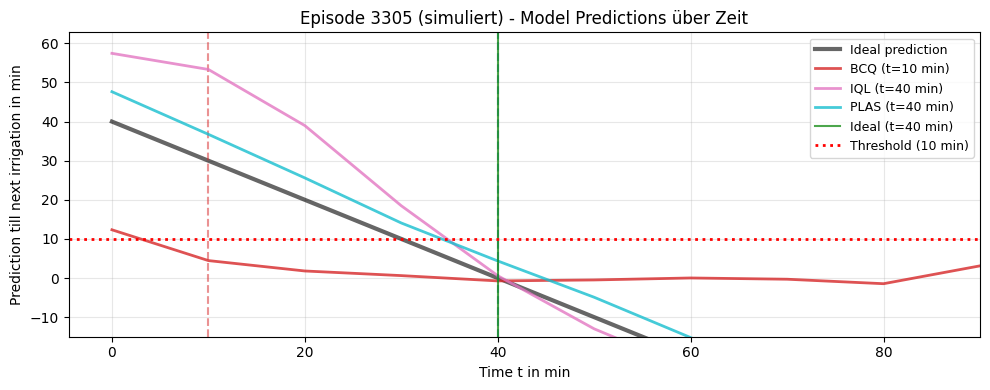


=== Zusammenfassung: Episode 3305 (simuliert) ===
Episode-Länge: 10 Schritte
Idealer Bewässerungszeitpunkt: Schritt 4
  BCQ: Trigger bei Schritt 1 (Offset: -3 Schritte = -30 min)
  IQL: Trigger bei Schritt 4 (Offset: +0 Schritte = +0 min)
  PLAS: Trigger bei Schritt 4 (Offset: +0 Schritte = +0 min)
--------------------------------------------------------------------------------


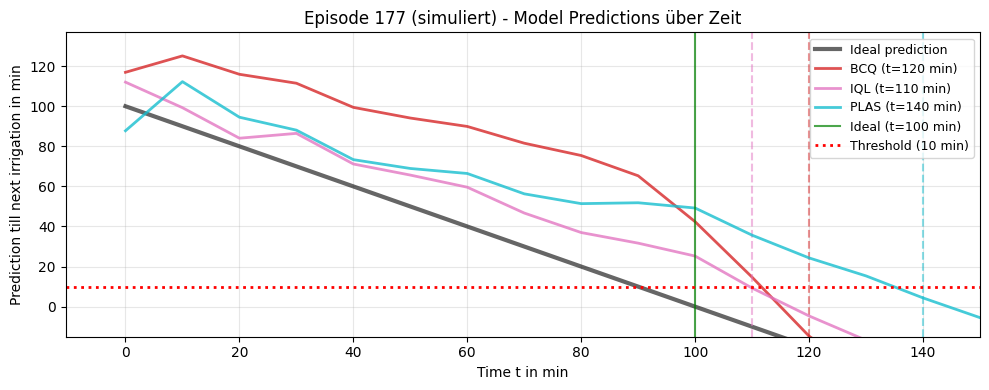


=== Zusammenfassung: Episode 177 (simuliert) ===
Episode-Länge: 22 Schritte
Idealer Bewässerungszeitpunkt: Schritt 10
  BCQ: Trigger bei Schritt 12 (Offset: +2 Schritte = +20 min)
  IQL: Trigger bei Schritt 11 (Offset: +1 Schritte = +10 min)
  PLAS: Trigger bei Schritt 14 (Offset: +4 Schritte = +40 min)
--------------------------------------------------------------------------------


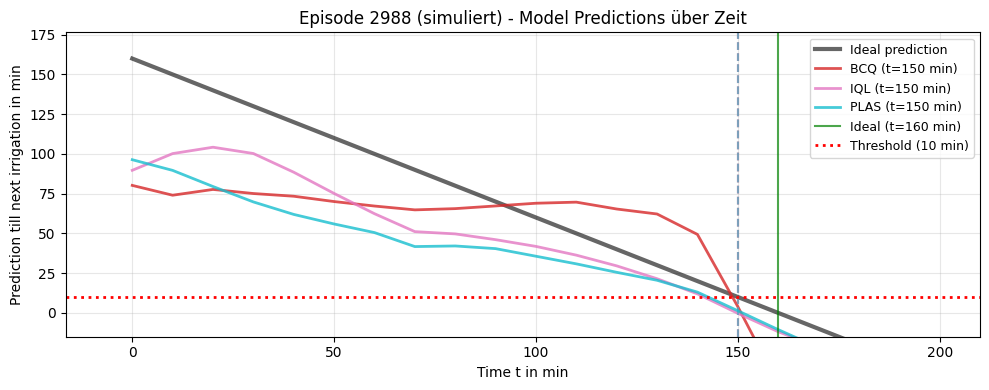


=== Zusammenfassung: Episode 2988 (simuliert) ===
Episode-Länge: 34 Schritte
Idealer Bewässerungszeitpunkt: Schritt 16
  BCQ: Trigger bei Schritt 15 (Offset: -1 Schritte = -10 min)
  IQL: Trigger bei Schritt 15 (Offset: -1 Schritte = -10 min)
  PLAS: Trigger bei Schritt 15 (Offset: -1 Schritte = -10 min)
--------------------------------------------------------------------------------


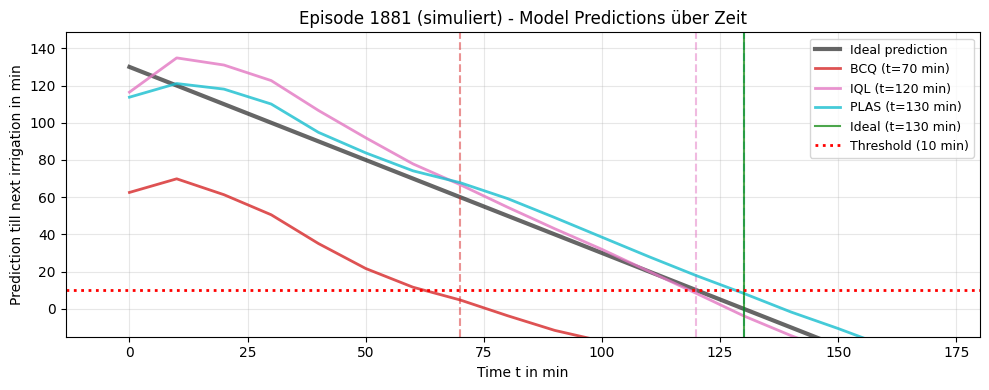


=== Zusammenfassung: Episode 1881 (simuliert) ===
Episode-Länge: 28 Schritte
Idealer Bewässerungszeitpunkt: Schritt 13
  BCQ: Trigger bei Schritt 7 (Offset: -6 Schritte = -60 min)
  IQL: Trigger bei Schritt 12 (Offset: -1 Schritte = -10 min)
  PLAS: Trigger bei Schritt 13 (Offset: +0 Schritte = +0 min)
--------------------------------------------------------------------------------
GEMESSENE EPISODEN


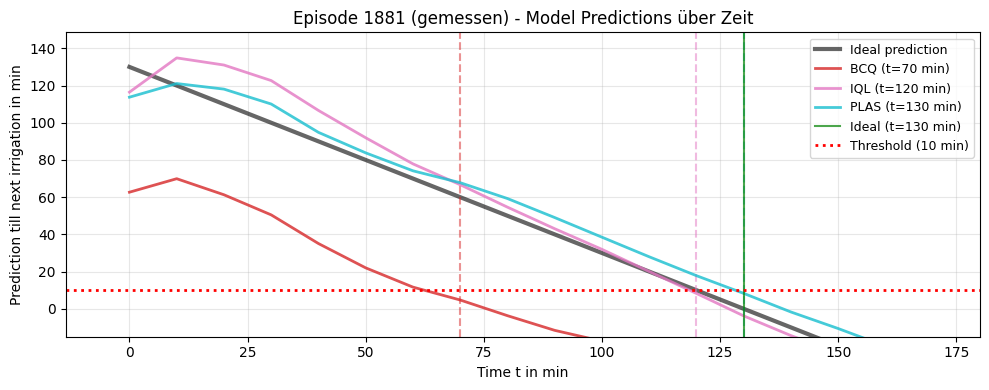


=== Zusammenfassung: Episode 1881 (gemessen) ===
Episode-Länge: 28 Schritte
Idealer Bewässerungszeitpunkt: Schritt 13
  BCQ: Trigger bei Schritt 7 (Offset: -6 Schritte = -60 min)
  IQL: Trigger bei Schritt 12 (Offset: -1 Schritte = -10 min)
  PLAS: Trigger bei Schritt 13 (Offset: +0 Schritte = +0 min)



IndexError: list index out of range

In [58]:
# === 10 zufällige Episoden plotten (Simuliert) ===
import random

n_episodes_to_plot = min(10, len(episodes_sim))
random_indices_sim = random.sample(range(len(episodes_sim)), n_episodes_to_plot)

print(f"Plotte {n_episodes_to_plot} zufällige SIMULIERTE Episoden aus {len(episodes_sim)} verfügbaren")
print(f"Ausgewählte Indizes: {sorted(random_indices_sim)}\n")

for episode_idx in random_indices_sim:
    selected_episode = episodes_sim[episode_idx]
    plot_episode_with_models(selected_episode, all_models, obs_indices, ideal_irri_index, f"Episode {episode_idx} (simuliert)")
    print("-" * 80)
print("GEMESSENE EPISODEN")    
plot_episode_with_models(selected_episode, all_models, obs_indices, ideal_irri_index, f"Episode {episode_idx} (gemessen)")

print("=" * 80 + "\n")    
selected_episode = episodes_meas[episode_idx]

for episode_idx in random_indices_meas:

    n_episodes_to_plot_meas = min(10, len(episodes_meas))

random_indices_meas = random.sample(range(len(episodes_meas)), n_episodes_to_plot_meas)
print(f"Ausgewählte Indizes: {sorted(random_indices_meas)}\n")

print(f"Plotte {n_episodes_to_plot_meas} zufällige GEMESSENE Episoden aus {len(episodes_meas)} verfügbaren")